In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("Mental Health Dataset.csv")
df.head()


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


##### Data Preparation

In [3]:
# null check
df.isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [4]:
# fill "unknown" for null values
df['self_employed'].isnull().sum()
df['self_employed'] = df['self_employed'].fillna('unknown')

In [5]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [6]:
df.dtypes

Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits             object
Mental_Health_History      object
Mood_Swings                object
Coping_Struggles           object
Work_Interest              object
Social_Weakness            object
mental_health_interview    object
care_options               object
dtype: object

In [7]:
# change to timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.dtypes

Timestamp                  datetime64[ns]
Gender                             object
Country                            object
Occupation                         object
self_employed                      object
family_history                     object
treatment                          object
Days_Indoors                       object
Growing_Stress                     object
Changes_Habits                     object
Mental_Health_History              object
Mood_Swings                        object
Coping_Struggles                   object
Work_Interest                      object
Social_Weakness                    object
mental_health_interview            object
care_options                       object
dtype: object

In [8]:
# extract year and month from timestamp
df['Year'] = df['Timestamp'].dt.year
df['Month_No'] = df['Timestamp'].dt.month
df['Month'] = df['Timestamp'].dt.month_name()

In [9]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August


##### Data Visualization

##### Taking Treatment Rate

In [14]:
taking_treatment_rate = (len(df[ df['treatment']=='Yes'] )/len(df['treatment'])) *100
taking_treatment_rate

50.48706407081583

##### Support Awareness Rate


In [17]:
support_awareness_rate = round((len(df[ df['care_options']=='Yes'])/ len(df['care_options']))*100,2)
support_awareness_rate

32.74

##### Growing Stress Rate

In [18]:
growing_stress_rate = round((len(df[ df['Growing_Stress']=='Yes'])/ len(df['Growing_Stress']))*100,2)
growing_stress_rate

34.09

In [22]:
filtered_df = df[df['treatment']=='Yes']
rates = df.groupby('Occupation')['treatment'].value_counts(normalize=True) * 100
rates

Occupation  treatment
Business    Yes          50.740792
            No           49.259208
Corporate   No           50.283362
            Yes          49.716638
Housewife   Yes          50.382059
            No           49.617941
Others      Yes          50.886622
            No           49.113378
Student     Yes          50.815613
            No           49.184387
Name: proportion, dtype: float64

In [23]:
rates.loc[:,'Yes']

Occupation
Business     50.740792
Corporate    49.716638
Housewife    50.382059
Others       50.886622
Student      50.815613
Name: proportion, dtype: float64

##### treatment percentage

In [10]:
# treatment analysis
treatment_analysis = df['treatment'].value_counts().reset_index(name='Count')
px.pie(
    treatment_analysis,
    names='treatment',
    values='Count',
    title='Contribution of Treatment'
)

##### Analysis of Taking Treatment over Year


In [26]:
taking_treatment = df[ df['treatment']=='Yes' ]
taking_treatment['treatment'].value_counts()

treatment
Yes    147606
Name: count, dtype: int64

In [27]:
df['Year'].value_counts()

Year
2014    277280
2015     14694
2016       390
Name: count, dtype: int64

In [28]:
taking_treatment_by_year =  taking_treatment.groupby('Year')['treatment'].size().reset_index(name='Count')
taking_treatment_by_year

,Year,Count
0,2014,137680
1,2015,9536
2,2016,390


In [29]:
px.line(
    taking_treatment_by_year,
    x='Year',
    y='Count',
    title='Taking Treatment over Years'
)

##### Top 10 countries with treatment

In [14]:
# Top 10 countries with treatment
top_10_list = df[ df['treatment']=='Yes' ]['Country'].value_counts().nlargest(10).index
top_10_list


Index(['United States', 'United Kingdom', 'Canada', 'Australia', 'Ireland',
       'Germany', 'Netherlands', 'New Zealand', 'South Africa', 'India'],
      dtype='object', name='Country')

In [15]:
# filter top 10 
df_top10 =df[ df['Country'].isin(top_10_list) ]
df_top10.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August


In [16]:
#top_10_treatment_by_countries
top_10_treatment_by_countries = df_top10.groupby( ['Country', 'treatment'] ).size().reset_index(name='Count').sort_values(by='Count', ascending=False)
top_10_treatment_by_countries

,Country,treatment,Count
19,United States,Yes,93032
18,United States,No,78276
16,United Kingdom,No,26004
17,United Kingdom,Yes,25400
3,Canada,Yes,10102
2,Canada,No,8624
10,Netherlands,No,3944
1,Australia,Yes,3642
8,Ireland,No,2818
9,Ireland,Yes,2730


In [17]:
# Top 10 of countries with treatment
px.bar(top_10_treatment_by_countries,
       x='Country',
       y='Count',
       title='Top 10 Countries of Treatment',
       color='treatment'
       )

##### Top 10 Countries for taking Treatments by Gender

In [18]:
df_top10.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August


In [19]:
top_10_countries_of_taking_treatment = df_top10[ df_top10['treatment']=='Yes' ]
top_10_countries_of_taking_treatment

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292357,2015-05-06 10:14:00,Male,Australia,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,5,May
292359,2015-07-27 23:25:00,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure,2015,7,July
292360,2015-08-17 09:38:00,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,8,August
292362,2015-09-26 01:07:00,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,9,September


In [20]:
top_10_countries_of_taking_treatment['treatment'].value_counts()

treatment
Yes    142838
Name: count, dtype: int64

In [21]:
top_10_countries_of_taking_treatment_by_gender = top_10_countries_of_taking_treatment.groupby( ['Country', 'Gender']).size().reset_index(name='Count').sort_values(by='Count',ascending=False)
top_10_countries_of_taking_treatment_by_gender

,Country,Gender,Count
16,United States,Male,67860
15,United States,Female,25172
14,United Kingdom,Male,21060
3,Canada,Male,6630
13,United Kingdom,Female,4340
2,Canada,Female,3472
7,Ireland,Male,2730
4,Germany,Male,2340
1,Australia,Male,2340
8,Netherlands,Male,1950


In [22]:
px.bar(
    top_10_countries_of_taking_treatment_by_gender,
    x='Country',
    y='Count',
    color='Gender',
    title='Top 10 Countries for taking Treatment by Gender'
)

##### Top 10 Countries of Taking Treatment by Occupation

In [23]:
top_10_countries_of_taking_treatment

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292357,2015-05-06 10:14:00,Male,Australia,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,5,May
292359,2015-07-27 23:25:00,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure,2015,7,July
292360,2015-08-17 09:38:00,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,8,August
292362,2015-09-26 01:07:00,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,9,September


In [24]:
top_10_countries_of_taking_treatment['treatment'].value_counts()

treatment
Yes    142838
Name: count, dtype: int64

In [25]:
top_10_countries_of_taking_treatment_by_occupation = top_10_countries_of_taking_treatment.groupby( ['Country', 'Occupation']).size().reset_index(name='Count').sort_values(by='Count', ascending=False)
top_10_countries_of_taking_treatment_by_occupation

,Country,Occupation,Count
47,United States,Housewife,21054
49,United States,Student,19836
46,United States,Corporate,19082
48,United States,Others,16994
45,United States,Business,16066
42,United Kingdom,Housewife,5766
44,United Kingdom,Student,5364
41,United Kingdom,Corporate,5330
43,United Kingdom,Others,4586
40,United Kingdom,Business,4354


In [26]:
px.bar(
    top_10_countries_of_taking_treatment_by_occupation,
    x='Country',
    y='Count',
    color='Occupation',
    title='Top 10 Countries for taking Treatment by Occupation'
)

##### Taking Treatment by 'Gender'='Male' of those top 10 countries

In [27]:
top_10_countries_of_taking_treatment_by_male = top_10_countries_of_taking_treatment[top_10_countries_of_taking_treatment['Gender'] == 'Male']
top_10_countries_of_taking_treatment_by_male

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
52515,2014-08-27 11:29:00,Male,United Kingdom,Others,unknown,Yes,Yes,31-60 days,Yes,Maybe,No,High,No,No,Yes,Maybe,Yes,2014,8,August
52519,2014-08-27 11:32:00,Male,United States,Others,unknown,No,Yes,31-60 days,Yes,Maybe,No,High,No,No,Yes,No,No,2014,8,August
52522,2014-08-27 11:34:00,Male,United Kingdom,Others,unknown,No,Yes,31-60 days,Yes,Maybe,No,High,No,No,Yes,Maybe,No,2014,8,August
52523,2014-08-27 11:34:00,Male,United States,Others,unknown,No,Yes,31-60 days,Yes,Maybe,No,High,No,No,Yes,No,Yes,2014,8,August
52525,2014-08-27 11:35:00,Male,United States,Others,No,Yes,Yes,31-60 days,Yes,Maybe,No,High,No,No,Yes,No,Yes,2014,8,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292357,2015-05-06 10:14:00,Male,Australia,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,5,May
292359,2015-07-27 23:25:00,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure,2015,7,July
292360,2015-08-17 09:38:00,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,8,August
292362,2015-09-26 01:07:00,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes,2015,9,September


In [28]:
top_10_countries_of_taking_treatment_by_male['Gender'].value_counts()

Gender
Male    107250
Name: count, dtype: int64

In [29]:
taking_treatment_by_male = top_10_countries_of_taking_treatment_by_male.groupby(['Country', 'Occupation']).size().reset_index(name='Count').sort_values(by='Count', ascending=False)
taking_treatment_by_male

,Country,Occupation,Count
47,United States,Housewife,15486
46,United States,Corporate,14790
49,United States,Student,14094
48,United States,Others,12006
45,United States,Business,11484
42,United Kingdom,Housewife,4806
41,United Kingdom,Corporate,4590
44,United Kingdom,Student,4374
43,United Kingdom,Others,3726
40,United Kingdom,Business,3564


In [38]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014,8,August


##### Most Effective Factors of Taking Treatment

In [30]:
# # top 3 factors
# # factors = ['self_employed', 'family_history', 'Growing_Stress', 'Mental_Health_History','Mood_Swings', 'Coping_Struggles','Social_Weakness']
# importance_factors = {}
# # calculate percentage of each of taking treatment
# for factor in factors:
#     percentage = df[ df['treatment']=='Yes' ][factor].value_counts()*100/len(df[ df['treatment']=='Yes' ])
#     print(f"Percentage of {factor} for taking treatment: \n{percentage}\n")

#     difference = percentage.max() - percentage.min()
#     importance_factors[factor] = difference

# importance_factors

# top_3_factors = sorted(importance_factors, key=importance_factors.get, reverse=True)[:3]
# top_3_factors


##### Correlation Check

In [31]:
# # convert to numeric
# df_numeric = df.copy()

# for factor in top_3_factors:
#     # df['numeric'][factor]
#     df_numeric[factor] = df_numeric[factor].map({'Yes':1, 'No':0, 'unknown':2})
# df_numeric.head()

In [32]:
# df_numeric['treatment'] = df_numeric['treatment'].map({'Yes':1, 'No':0})

In [33]:
# df_numeric.isnull().sum()

In [34]:
# col_to_plot = ['self_employed', 'family_history', 'Coping_Struggles', 'treatment']
# corr_matrix = df_numeric[col_to_plot].corr()
# plt.figure(figsize=(10,6))
# sns.heatmap(corr_matrix)

##### Correlation Analysis

In [35]:
df_numerics = df.copy()
df_numerics = df_numerics.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
# df_numerics = df_numerics.map({'Yes': 1, 'No':0, 'unknown':2, 'Maybe':2, 'Low':0, 'Medium':1, 'High':2, 'Not sure':2, '1-14 days':0, '15-30 days':1, '31-60 days':2, 'Go out Every day':3, 'More than 2 months':4})
binary_map = {'Yes': 1, 'No': 0, 'Maybe': 0.5, 'Not sure': 0.5, 'unknown': 0.5}
scale_map = {'Low': 0, 'Medium': 1, 'High': 2}
days_map = {'Go out Every day': 0, '1-14 days': 1, '15-30 days': 2, '31-60 days': 3, 'More than 2 months': 4}

# Apply the mapping (you can do this column by column or all at once)
# Example of applying it to all columns at once if they share values:
df_numerics = df_numerics.replace(binary_map)
df_numerics = df_numerics.replace(scale_map)
df_numerics = df_numerics.replace(days_map)

df_numerics.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13940\2192112895.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numerics = df_numerics.replace(binary_map)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13940\2192112895.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numerics = df_numerics.replace(scale_map)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13940\2192112895.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `res

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Year,Month_No,Month
0,2014-08-27 11:29:00,Female,United States,Corporate,0.5,0,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.5,2014,8,August
1,2014-08-27 11:31:00,Female,United States,Corporate,0.5,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.0,2014,8,August
2,2014-08-27 11:32:00,Female,United States,Corporate,0.5,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0,2014,8,August
3,2014-08-27 11:37:00,Female,United States,Corporate,0.0,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.5,1.0,2014,8,August
4,2014-08-27 11:43:00,Female,United States,Corporate,0.0,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0,2014,8,August


<Axes: >

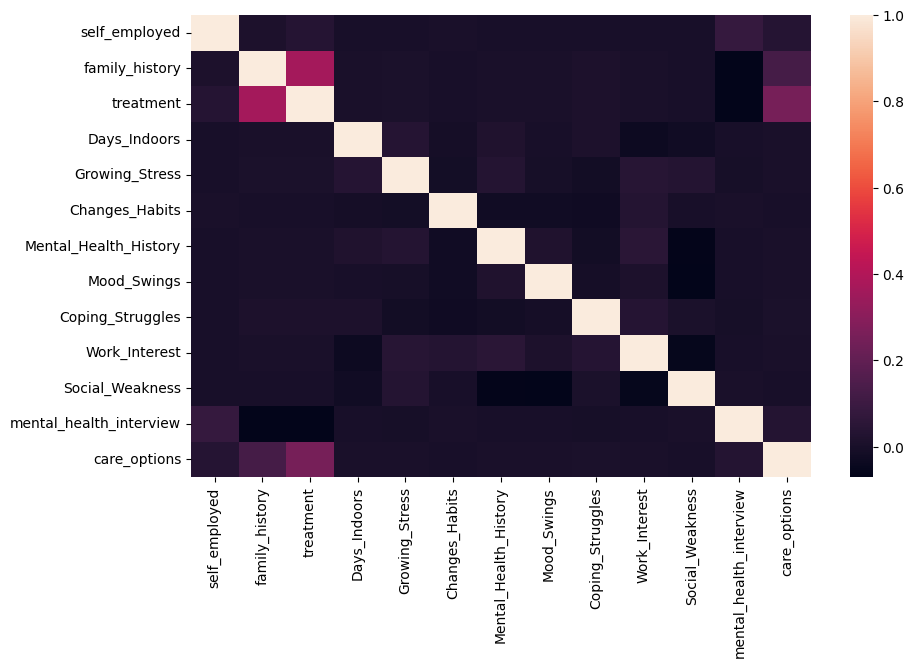

In [36]:
col_to_plot = ['self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']
corr_matrix = df_numerics[col_to_plot].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix)

In [37]:
df_numerics['treatment'].value_counts()

treatment
1    147606
0    144758
Name: count, dtype: int64